# Clustering jerárquico con huecos: sueño, salud y estilo de vida

Completa las celdas siguientes para aplicar:

- clustering jerárquico
- dendrograma
- análisis de clústeres
- comparación con K-Means
- Utiliza para la resolución https://scikit-learn.org/stable/ y https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

>El origen del Dataset es https://www.kaggle.com/

## Contexto del dataset

El dataset recoge hábitos de sueño, salud y estilo de vida de aproximadamente 400 personas. Cada fila representa un individuo. Las variables que usaremos son:

| Variable | Tipo | Rango / Valores | Qué mide |
|---|---|---|---|
| Age | Numérica | 27 – 59 | Edad en años |
| Sleep Duration | Numérica | 5.8 – 8.5 | Horas de sueño por noche |
| Quality of Sleep | Numérica | 1 – 10 | Calidad subjetiva del sueño |
| Physical Activity Level | Numérica | 30 – 90 | Minutos de actividad física diaria |
| Stress Level | Numérica | 1 – 10 | Nivel de estrés autopercibido |
| Heart Rate | Numérica | 65 – 86 | Pulsaciones en reposo (bpm) |
| Daily Steps | Numérica | 3.000 – 10.000 | Pasos diarios |

También existen variables categóricas como `Gender` y `Sleep Disorder` que no entran en el clustering pero pueden usarse para interpretar los grupos.

---

**Antes de ejecutar nada, analiza:**  
¿Qué variable crees que tendrá más peso a la hora de separar los grupos?  
¿Esperas que el género influya en los clústeres resultantes?

Anota tu hipótesis aquí y compárala con los resultados al final.

> *Mi hipótesis:*

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 2. Carga del dataset

In [2]:
df = pd.read_csv("clustering.csv", sep=",")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2b. Comprobación y tratamiento de valores nulos

Antes de continuar, verifica si el dataset tiene valores que deban tener un tratamiento específico.  
Esta decisión afecta a todo el análisis posterior.

In [3]:
# Nulos por columna
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [4]:
# ¿Qué porcentaje representa cada uno?
print((df.isnull().sum() / len(df) * 100).round(2))

Person ID                   0.00
Gender                      0.00
Age                         0.00
Occupation                  0.00
Sleep Duration              0.00
Quality of Sleep            0.00
Physical Activity Level     0.00
Stress Level                0.00
BMI Category                0.00
Blood Pressure              0.00
Heart Rate                  0.00
Daily Steps                 0.00
Sleep Disorder             58.56
dtype: float64


In [5]:
# Decide una estrategia y completa:
# Opción A — eliminar filas con nulos
# Opción B — imputar con la media
# Opción C — imputar con la mediana

df = df.dropna()   # Opción A, porque hay demasiados nulos, entonces si rellenamos con la media o mediana, no seria representativo.
# df[columnas] = df[columnas].fillna(df[columnas].median())  # Opción B o C

# Comprobación final: debe dar 0 en todas las columnas
print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


## 3. Exploración inicial

In [6]:
print("Filas y columnas:", df.shape)
print(df.columns.tolist())

Filas y columnas: (155, 13)
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


In [7]:
df.columns.tolist()

['Person ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'BMI Category',
 'Blood Pressure',
 'Heart Rate',
 'Daily Steps',
 'Sleep Disorder']

## 4. Selección de variables

Usa estas variables numéricas:
- Age
- Sleep Duration
- Quality of Sleep
- Physical Activity Level
- Stress Level
- Heart Rate
- Daily Steps

In [8]:
columnas = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

X = df[columnas]
X.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
3,28,5.9,4,30,8,85,3000
4,28,5.9,4,30,8,85,3000
5,28,5.9,4,30,8,85,3000
6,29,6.3,6,40,7,82,3500
16,29,6.5,5,40,7,80,4000


In [9]:
# Vamos a ver la correlacion entre las variables para entender cual es la mas relacionada
X.corr().abs()["Quality of Sleep"].sort_values(ascending=False)

Quality of Sleep           1.000000
Sleep Duration             0.916748
Stress Level               0.872084
Age                        0.710221
Heart Rate                 0.534720
Physical Activity Level    0.352021
Daily Steps                0.025166
Name: Quality of Sleep, dtype: float64

## 5. Escalado

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 6. Matriz de enlace

In [11]:
Z = linkage(X, method="ward")
Z[:5]

array([[  0.,   1.,   0.,   2.],
       [  2., 155.,   0.,   3.],
       [ 11.,  12.,   0.,   2.],
       [  4.,   6.,   0.,   2.],
       [  7.,   8.,   0.,   2.]])

## 7. Dendrograma

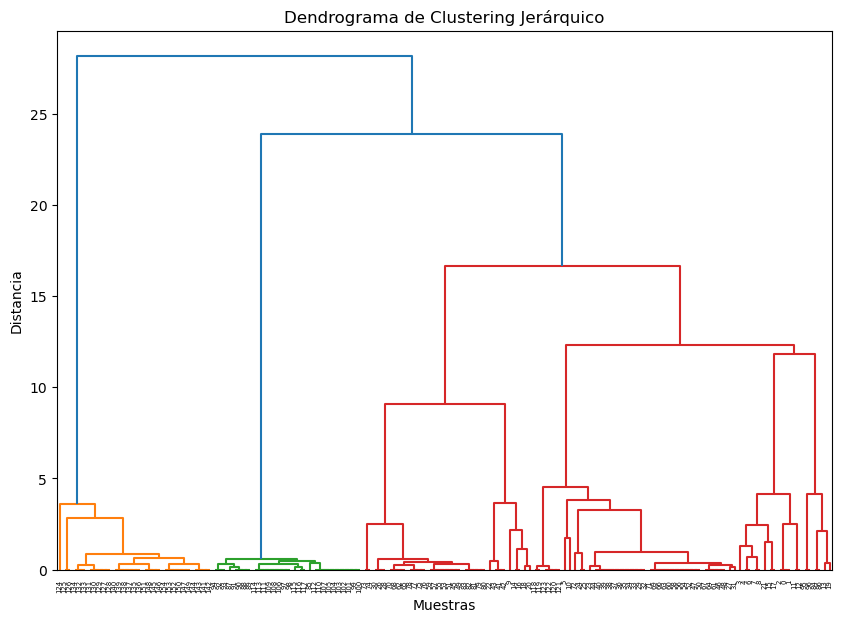

In [12]:
plt.figure(figsize=(10, 7,))
dendrogram(Z, p=3)
plt.title("Dendrograma de Clustering Jerárquico")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()

## 8. Número de clústeres

A partir del dendrograma, crea 3 clústeres.

In [13]:
clusters_h = fcluster(Z, t=4, criterion="maxclust")
df["cluster_jerarquico"] = clusters_h

## 9. Tamaño de cada clúster

In [14]:
df["cluster_jerarquico"].value_counts()

cluster_jerarquico
4    60
3    34
1    31
2    30
Name: count, dtype: int64

## 10. Perfil medio de cada clúster

In [15]:
perfil_h = df.groupby("cluster_jerarquico")[["Sleep Duration", "Quality of Sleep"]].mean().round(2)
perfil_h

,Sleep Duration,Quality of Sleep
cluster_jerarquico,,
1,8.10,9.00
2,6.06,6.00
3,6.83,7.24
4,6.51,6.00


## 11. Relación con género

In [16]:
pd.crosstab(df["cluster_jerarquico"], df["Sleep Duration"], normalize="index").round(3)

Sleep Duration,5.8,5.9,6.0,6.1,6.2,6.3,6.4,6.5,6.6,6.7,...,7.2,7.3,7.4,7.6,7.7,7.8,8.0,8.1,8.2,8.3
cluster_jerarquico,,,,,,,,,,,,,,,,,,,,,
1,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.323,0.355,0.29,0.032
2,0.000,0.033,0.400,0.467,0.1,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000
3,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.235,0.353,0.088,...,0.088,0.000,0.000,0.029,0.029,0.088,0.000,0.000,0.00,0.000
4,0.033,0.050,0.033,0.000,0.0,0.217,0.133,0.283,0.100,0.000,...,0.000,0.033,0.033,0.000,0.000,0.000,0.000,0.033,0.00,0.000


## 12. K-Means

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_k = kmeans.fit_predict(df[["Sleep Duration", "Quality of Sleep"]])
df["cluster_kmeans"] = clusters_k

## 13. Perfil medio en K-Means

In [18]:
perfil_k = df.groupby("cluster_kmeans")[["Sleep Duration", "Quality of Sleep"]].mean().round(2)
perfil_k

,Sleep Duration,Quality of Sleep
cluster_kmeans,,
0,8.06,8.89
1,6.24,5.78
2,6.75,7.10


## 14. Comparación entre métodos: Matriz de Confusión

> **Nota importante:** los números de clúster asignados por cada algoritmo son arbitrarios. El clúster "1" del jerárquico puede contener los mismos individuos que el clúster "2" de K-Means aunque sean el mismo grupo en la práctica. Interpreta la matriz fijándote en la **concentración de valores**, no en que coincidan los números.

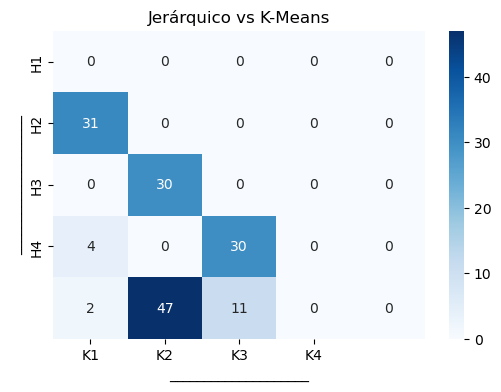

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Construye la matriz cruzando ambos métodos
matriz = confusion_matrix(df["cluster_jerarquico"], df["cluster_kmeans"])

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["K1", "K2", "K3", "K4"],
    yticklabels=["H1", "H2", "H3", "H4"]
)
plt.xlabel("____________________")
plt.ylabel("____________________")
plt.title("Jerárquico vs K-Means")
plt.show()

**Reflexiona:** ¿Qué significa que haya valores altos fuera de la diagonal?  
¿Coinciden bien los dos métodos o hay grupos que se mezclan?

> *Mi respuesta:*

## 15. Visualización

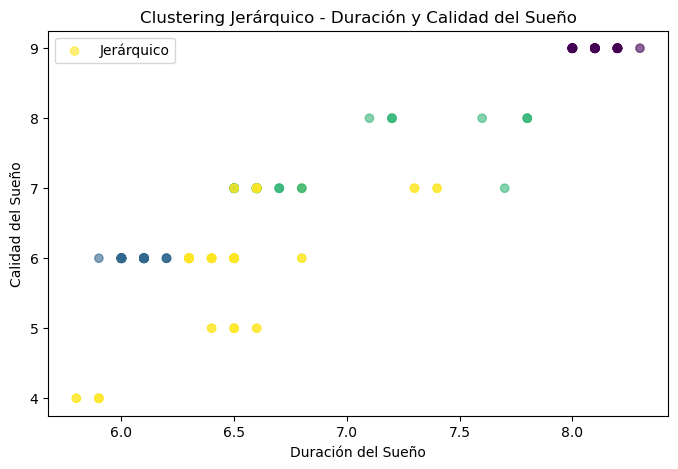

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sleep Duration"], df["Quality of Sleep"], c=df["cluster_jerarquico"], cmap="viridis", label="Jerárquico", alpha=0.6)
plt.xlabel("Duración del Sueño")
plt.ylabel("Calidad del Sueño")
plt.title("Clustering Jerárquico - Duración y Calidad del Sueño")
plt.legend()
plt.show()

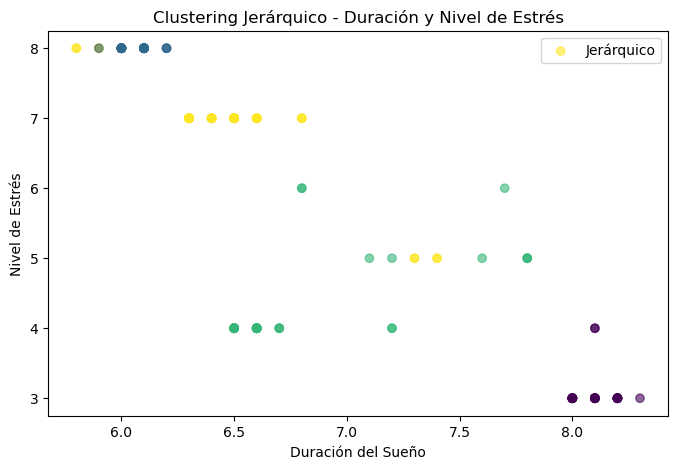

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sleep Duration"], df["Stress Level"], c=df["cluster_jerarquico"], cmap="viridis", label="Jerárquico", alpha=0.6)
plt.xlabel("Duración del Sueño")
plt.ylabel("Nivel de Estrés")
plt.title("Clustering Jerárquico - Duración y Nivel de Estrés")
plt.legend()
plt.show()

## 16. Cuestiones finales

Responde:

1. ¿Cuántos clústeres observas en el dendrograma?
    - Los distintos clusters se observan distinguidos mediante el color, según el resultado del dendrograma podremos observar 4 clústers distintos
2. ¿Cómo describirías cada grupo?
    - 1. El primer grupo, es el que cuenta con la menor cantidad de sueño y la menor calidad
    - 2. El segundo grupo es el que cuenta con una buena cantidad de sueño pero con poca calidad
    - 3. El tercer grupo es gente que tiene buena calidad de sueño pero muy poca cantidad de tiempo
    - 4. Y el último grupo es el que tiene la mayor cantidad de horas de sueño, y mayor calidad
3. ¿Qué variables distinguen mejor unos grupos de otros?
    - Las variables con mayor peso son o bien la calidad de sueño o el nivel de estres, esto lo he podido comprobar gracias a la correlación, la cual es muy alta (>0.88)
4. ¿Coinciden mucho los grupos jerárquicos y los de K-Means?
    - Por lo general coinciden, ya que si asignas correctamente el numero de grupos en KMeans van a llegar a la misma conclusión.
5. ¿Crees que las personas se agrupan más por género o por hábitos?
    - Las personas se agrupan más por hábitos y estado del sueño que por género, porque las diferencias más fuertes entre grupos están en estrés, calidad y duración del sueño.
6. ¿Se cumplió tu hipótesis inicial sobre qué variable tendría más peso?
    - Mas o menos, ya que duracion del sueño y calidad esperaba que tuviesen mucho peso como es el caso, pero no contaba con la importancia del nivel de estrés.